<h1 style="text-align:center;">ESCUELA POLITÉCNICA NACIONAL</h1>
<h2 style="text-align:center;">FACULTAD DE INGENIERÍA DE SISTEMAS</h2>
<h3 style="text-align:center;">INGENIERÍA EN COMPUTACIÓN</h3>


**PERÍODO ACADÉMICO:** 2025-B  
**ASIGNATURA:** ICCD412 Métodos Numéricos  
**GRUPO:** GR2  
**TIPO DE INSTRUMENTO:** PROYECTO SEGUNDO BIMESTRE  
**FECHA DE ENTREGA LÍMITE:** 05/02/2026  
**ALUMNO:** Nicolás Yugsi, Sebastián Bravo, Erick Toapanta, Heidy Tenelema.


### FASE 1: Preprocesamiento, Aritmética y Linealización Temporal

En esta primera etapa, preparamos el dataset para que sea apto para el análisis numérico. Los desafíos identificados son:

*   **Formato de Datos:** Los precios se encuentran en formato de texto con separadores de miles innecesarios.
*   **Aritmética de Punto Flotante:** Convertiremos los valores al estándar **IEEE 754 (float64)** para garantizar que los errores de redondeo en cálculos futuros (como derivadas o integrales) sean mínimos.
*   **Variable Independiente:** Los modelos matemáticos requieren un eje numérico. Crearemos la variable $t$, donde cada unidad representa una hora de mercado.


In [ ]:
#@title FASE 1: Carga, Inspección y Preprocesamiento
import pandas as pd
import numpy as np

# --- 1. CARGA INICIAL Y RECONOCIMIENTO DEL DATASET ---
archivo = 'CRYPTO_BTC_USD.csv'
try:
    df_total = pd.read_csv(archivo, sep=';')

    # Conversión a datetime y eliminación de zona horaria para estandarización
    df_total['open_time'] = pd.to_datetime(df_total['open_time']).dt.tz_localize(None)

    # Identificación de límites absolutos del archivo
    limite_minimo = df_total['open_time'].min()
    limite_maximo = df_total['open_time'].max()

    print("INFORMACION DEL DATASET CARGADO")
    print(f"Inicio del registro histórico: {limite_minimo}")
    print(f"Fin del registro histórico:    {limite_maximo}")
    print(f"Total de registros:            {len(df_total)}")
    print("-" * 50)

except Exception as e:
    print(f"ERROR CRITICO AL CARGAR EL DATASET: {e}")

# --- 2. DEFINICIÓN DE PARÁMETROS DE USUARIO ---
# El usuario ingresa su intervalo de interés basado en la información anterior
fecha_inicio_usuario = '2017-08-20' #@param {type:"string"}
fecha_fin_usuario    = '2017-08-30' #@param {type:"string"}

# --- 3. VALIDACIÓN Y SEGMENTACIÓN DE DATOS ---
try:
    inicio_dt = pd.to_datetime(fecha_inicio_usuario)
    fin_dt    = pd.to_datetime(fecha_fin_usuario)

    if inicio_dt < limite_minimo or fin_dt > limite_maximo:
        print("ERROR DE RANGO: Las fechas seleccionadas están fuera del historial disponible.")
        print("Por favor, ajuste los parámetros dentro de los límites mostrados arriba.")
    elif inicio_dt >= fin_dt:
        print("ERROR LÓGICO: La fecha de inicio debe ser anterior a la fecha final.")
    else:
        # Filtrado del intervalo seleccionado
        mascara = (df_total['open_time'] >= inicio_dt) & (df_total['open_time'] <= fin_dt)
        df_analisis = df_total.loc[mascara].copy()

        # --- 4. LIMPIEZA Y TRANSFORMACIÓN IEEE 754 ---
        def normalizar_valor(texto):
            """Convierte formato de texto con separadores a float64 estándar."""
            if isinstance(texto, str):
                return float(texto.replace('.', '')) / 100000000
            return texto

        columnas_precio = ['open_price', 'high_price', 'low_price', 'close_price']
        for col in columnas_precio:
            df_analisis[col] = df_analisis[col].apply(normalizar_valor)

        # Generación de variable independiente t (linealización)
        # t=0 corresponde al primer registro del intervalo seleccionado
        df_analisis['t'] = np.arange(len(df_analisis))

        # --- 5. SALIDA DE VERIFICACIÓN ---
        print("\nPROCESAMIENTO DE DATOS COMPLETADO")
        print(f"Ventana de análisis: {inicio_dt.date()} a {fin_dt.date()}")
        print(f"Puntos (n) para cálculo numérico: {len(df_analisis)}")
        print("\nMuestra de las primeras filas procesadas:")
        print(df_analisis[['open_time', 't', 'close_price']].head())

except Exception as e:
    print(f"ERROR EN EL PROCESAMIENTO: {e}")

INFORMACION DEL DATASET CARGADO
Inicio del registro histórico: 2017-08-18 13:00:00
Fin del registro histórico:    2018-10-11 19:00:00
Total de registros:            10000
--------------------------------------------------

PROCESAMIENTO DE DATOS COMPLETADO
Ventana de análisis: 2017-08-20 a 2017-08-30
Puntos (n) para cálculo numérico: 241

Muestra de las primeras filas procesadas:
             open_time  t  close_price
35 2017-08-20 00:00:00  0      4086.09
36 2017-08-20 01:00:00  1      4082.53
37 2017-08-20 02:00:00  2      4124.69
38 2017-08-20 03:00:00  3      4094.62
39 2017-08-20 04:00:00  4      4093.00


## FASE 2: Representación de la Dinámica del Precio y Rango de Volatilidad

En esta fase visualizamos el segmento de datos seleccionado para entender la relación entre el tiempo lineal ($t$) y la variación del precio en USD.

**Interpretación Técnica:**
1. **Escala Temporal:** El eje horizontal representa las horas transcurridas desde el inicio del intervalo ($t=0$). Un valor de 3500 indica que se están analizando 3500 horas de mercado.
2. **Túnel de Incertidumbre:** La franja sombreada representa el área entre el precio máximo y mínimo de cada hora. Su grosor indica visualmente la volatilidad: a mayor grosor, mayor riesgo y dificultad para el modelado numérico.
3. **Trayectoria de Cierre:** La línea central es el precio de cierre, que utilizaremos como base para nuestras futuras estimaciones.

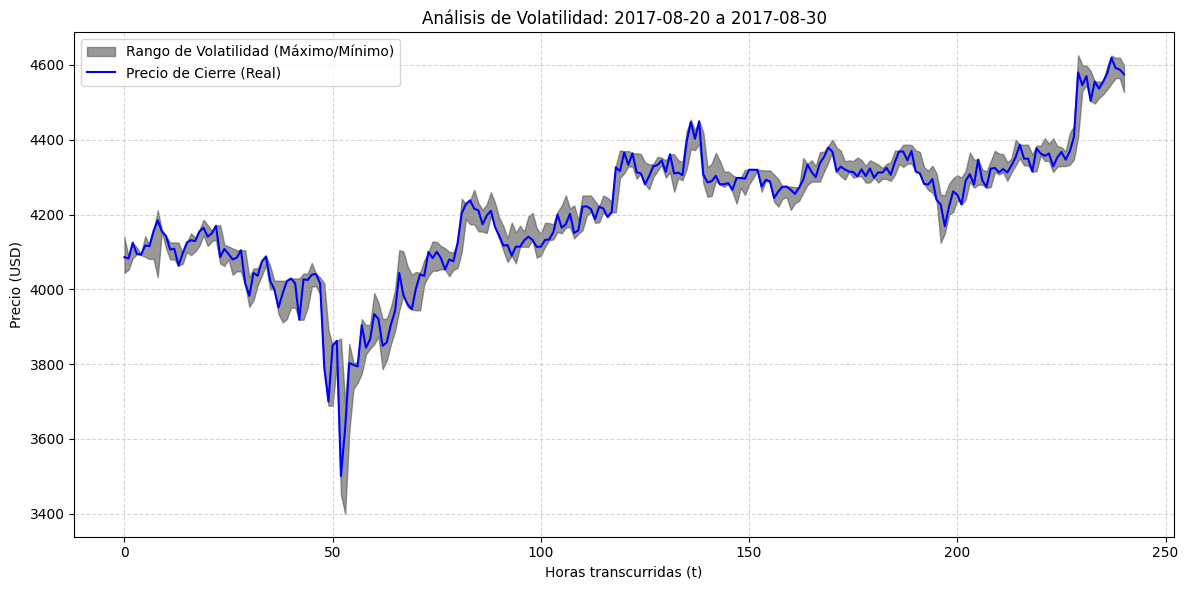

ESTADÍSTICAS DEL PERIODO:
- Total de horas (t_max): 240
- Precio Mínimo registrado: $3,400.00
- Precio Máximo registrado: $4,625.85


In [ ]:
#@title FASE 2: Análisis de Volatilidad
import matplotlib.pyplot as plt

# --- 1. CONFIGURACIÓN DEL LIENZO ---
plt.figure(figsize=(12, 6))

# --- 2. DIBUJO DE LA VOLATILIDAD (Sombra Oscura) ---
plt.fill_between(
    df_analisis['t'],
    df_analisis['low_price'],
    df_analisis['high_price'],
    color='#555555',
    alpha=0.6,
    label='Rango de Volatilidad (Máximo/Mínimo)'
)

# --- 3. DIBUJO DEL PRECIO DE CIERRE ---
plt.plot(
    df_analisis['t'],
    df_analisis['close_price'],
    color='blue',
    linewidth=1.5,
    label='Precio de Cierre (Real)'
)

# --- 4. FORMATO TÉCNICO ETIQUETADO ---
plt.title(f'Análisis de Volatilidad: {inicio_dt.date()} a {fin_dt.date()}')
plt.xlabel('Horas transcurridas (t)')
plt.ylabel('Precio (USD)')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='upper left')

# --- 5. AJUSTE DE ESCALA (ZOOM VERTICAL) ---
margen_y = (df_analisis['high_price'].max() - df_analisis['low_price'].min()) * 0.05
plt.ylim(
    df_analisis['low_price'].min() - margen_y,
    df_analisis['high_price'].max() + margen_y
)

plt.tight_layout()
plt.show()

# --- 6. DATOS DE CONTROL PARA EL INFORME ---
print("ESTADÍSTICAS DEL PERIODO:")
print(f"- Total de horas (t_max): {df_analisis['t'].max()}")
print(f"- Precio Mínimo registrado: ${df_analisis['low_price'].min():,.2f}")
print(f"- Precio Máximo registrado: ${df_analisis['high_price'].max():,.2f}")

## FASE 3: Modelado de Tendencia mediante Regresión por Mínimos Cuadrados

En esta fase, transformamos los datos discretos del precio en una función continua $f(t)$ que represente la tendencia principal del mercado. Para ello, aplicamos el método de **Mínimos Cuadrados**.

**Fundamento Matemático:**
El objetivo es encontrar los coeficientes de un polinomio de grado $n$ que minimice la suma de los cuadrados de las diferencias (residuos) entre los precios reales ($y_i$) y los valores calculados por nuestra función ($f(t_i)$):

$$\min \sum_{i=0}^{m} [y_i - f(t_i)]^2$$

**Utilidad en el Proyecto:**
1. **Reducción de Ruido:** Filtramos las fluctuaciones aleatorias del mercado para identificar la dirección estructural del precio.
2. **Obtención de una Ecuación:** Generamos una expresión matemática analítica que nos permitirá realizar estimaciones fuera del rango de datos actual.
3. **Análisis de Aceleración:** Dependiendo del grado del polinomio (lineal o cuadrático), podremos determinar no solo la dirección, sino si el movimiento del precio se está acelerando o desacelerando.

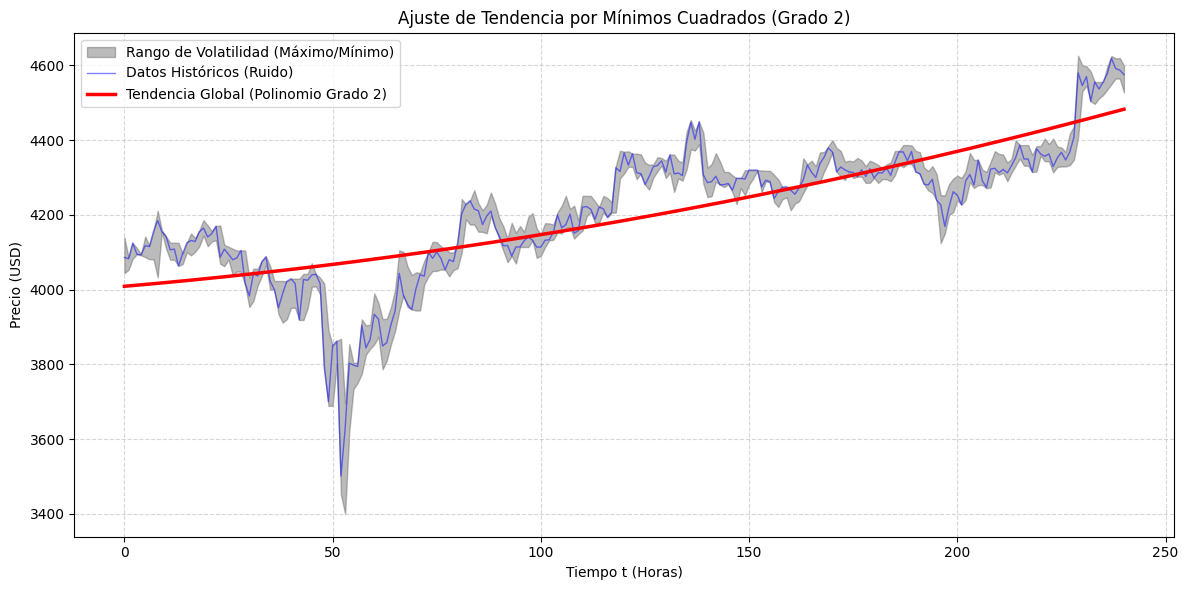

--- RESULTADOS DEL MODELADO ---
Coeficientes del polinomio (de mayor a menor grado):
[4.22635555e-03 9.59838371e-01 4.00887017e+03]

Ecuación Polinomial f(t):
          2
0.004226 x + 0.9598 x + 4009

Interpretación:
Esta función matemática minimiza el error cuadrático global y representa la dirección estructural del mercado.


In [ ]:
#@title FASE 3: Modelado de Tendencia (Regresión por Mínimos Cuadrados)
import numpy as np
import matplotlib.pyplot as plt

# --- 1. CONFIGURACIÓN DEL MODELO ---
# @markdown Seleccione el grado del polinomio (1: Lineal, 2: Cuadrático, 3: Cúbico):
grado_deseado = 2 #@param {type:"slider", min:1, max:3, step:1}

# --- 2. CÁLCULO MATEMÁTICO (Mínimos Cuadrados) ---
# t es nuestra variable independiente y close_price la dependiente
t_valores = df_analisis['t'].values
y_valores = df_analisis['close_price'].values

# np.polyfit aplica el método de mínimos cuadrados para encontrar los coeficientes
coeficientes = np.polyfit(t_valores, y_valores, grado_deseado)

# Construimos la función polinomial f(t)
modelo_tendencia = np.poly1d(coeficientes)

# Evaluamos la función en todo el dominio t para graficar la curva suave
y_tendencia = modelo_tendencia(t_valores)

# --- 3. VISUALIZACIÓN TÉCNICA COMBINADA ---
plt.figure(figsize=(12, 6))

# A. Banda de Volatilidad (Consistencia Fase 2 - Gris Oscuro)
plt.fill_between(
    t_valores,
    df_analisis['low_price'],
    df_analisis['high_price'],
    color='#555555',
    alpha=0.4,
    label='Rango de Volatilidad (Máximo/Mínimo)'
)

# B. Precio de Cierre Real (Consistencia Fase 2 - Azul)
plt.plot(
    t_valores,
    y_valores,
    color='blue',
    alpha=0.5,
    linewidth=1,
    label='Datos Históricos (Ruido)'
)

# C. Línea de Tendencia (Modelo Calculado - Rojo Intenso)
plt.plot(
    t_valores,
    y_tendencia,
    color='red',
    linewidth=2.5,
    label=f'Tendencia Global (Polinomio Grado {grado_deseado})'
)

# --- 4. FORMATO ACADÉMICO ---
plt.title(f'Ajuste de Tendencia por Mínimos Cuadrados (Grado {grado_deseado})')
plt.xlabel('Tiempo t (Horas)')
plt.ylabel('Precio (USD)')
plt.legend(loc='upper left')
plt.grid(True, which='both', linestyle='--', alpha=0.5)

# Ajuste de escala para centrar la visualización
margen_y = (df_analisis['high_price'].max() - df_analisis['low_price'].min()) * 0.05
plt.ylim(df_analisis['low_price'].min() - margen_y, df_analisis['high_price'].max() + margen_y)

plt.tight_layout()
plt.show()

# --- 5. REPORTE DE LA ECUACIÓN ---
print("--- RESULTADOS DEL MODELADO ---")
print(f"Coeficientes del polinomio (de mayor a menor grado):")
print(coeficientes)
print("\nEcuación Polinomial f(t):")
print(modelo_tendencia)
print("\nInterpretación:")
print("Esta función matemática minimiza el error cuadrático global y representa la dirección estructural del mercado.")

## FASE 4: Interpolación y Suavizado mediante Splines Cúbicos

En esta fase, aplicamos la interpolación por **Splines Cúbicos** para obtener una función continua $S(t)$ que represente fielmente la trayectoria del precio.

**Fundamento Matemático:**
A diferencia de los polinomios globales, los Splines cúbicos se definen por tramos, garantizando la continuidad de la función y de sus dos primeras derivadas ($S'(t)$ y $S''(t)$). Esto evita las oscilaciones artificiales (Fenómeno de Runge) y proporciona una curva suave que es analíticamente derivable.

**Ventajas Técnicas:**
1. **Fidelidad de Datos:** La curva intercepta todos los puntos observados de la serie temporal.
2. **Derivabilidad:** La suavidad de la curva permite el cálculo preciso de la tasa de variación del precio.
3. **Validación:** Se comparará esta interpolación con el túnel de volatilidad para confirmar que el suavizado no distorsiona la realidad del mercado.

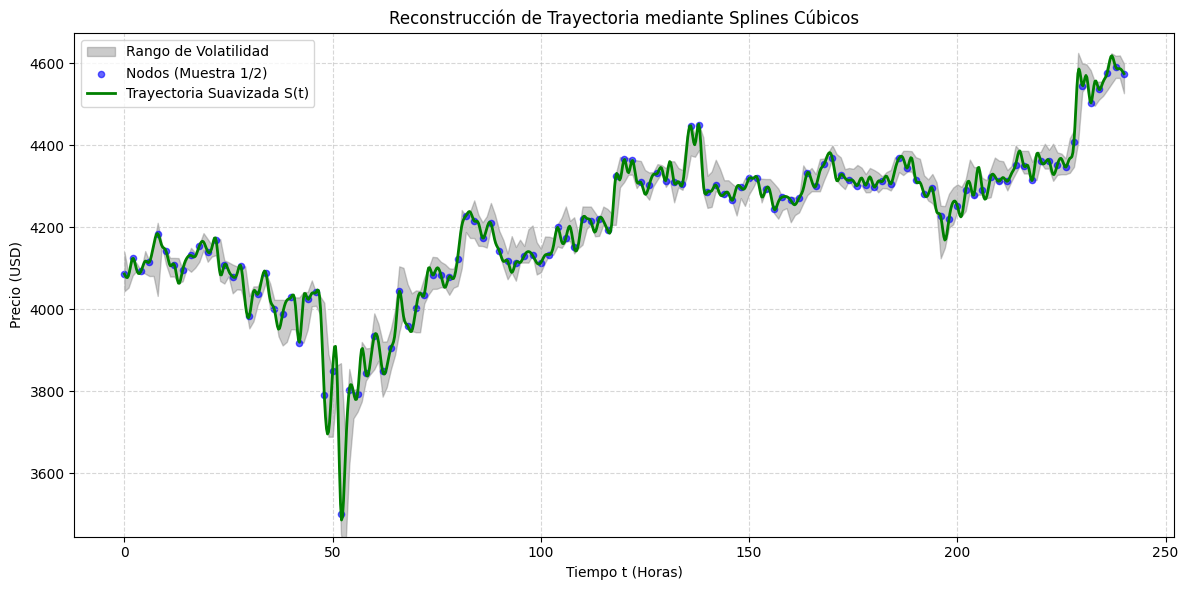

--- ANÁLISIS DE LA INTERPOLACIÓN ---
1. Estructura Matemática:
   - Total de nodos procesados: 241
   - Polinomios cúbicos generados: 240

2. Dinámica del Mercado (Basado en S'(t)):
   - Aceleración alcista máx: +$250.75 USD/h
   - Aceleración bajista máx: $-261.76 USD/h


In [ ]:
#@title FASE 4: Interpolación y Suavizado (Splines Cúbicos)
from scipy.interpolate import CubicSpline
import numpy as np
import matplotlib.pyplot as plt

# --- 1. PREPARACIÓN DE DATOS ---
t_datos = df_analisis['t'].values
y_datos = df_analisis['close_price'].values
n_total = len(t_datos)

# --- 2. CÁLCULO DEL SPLINE CÚBICO (Matemática Rigurosa) ---
# Se calcula usando EL 100% de los datos para garantizar precisión en derivadas
spline = CubicSpline(t_datos, y_datos, bc_type='natural')

# Generamos dominio denso para graficar la curva
t_suave = np.linspace(t_datos.min(), t_datos.max(), 1000)
y_spline = spline(t_suave)

# --- 3. CÁLCULO DE DERIVADAS ---
velocidad = spline(t_datos, 1)

# --- 4. OPTIMIZACIÓN VISUAL (SOLUCIÓN AL RUIDO) ---
# Si hay demasiados puntos, no graficamos todos los nodos, solo una muestra representativa
# Esto limpia el gráfico pero MANTIENE la curva verde exacta.
if n_total > 200:
    paso_visual = int(n_total / 100) # Muestra aprox 100 puntos distribuidos uniformemente
    etiqueta_puntos = f'Nodos (Muestra 1/{paso_visual})'
else:
    paso_visual = 1
    etiqueta_puntos = 'Nodos (Todos)'

# --- 5. VISUALIZACIÓN TÉCNICA ---
plt.figure(figsize=(12, 6))

# A. Banda de Volatilidad
plt.fill_between(
    t_datos,
    df_analisis['low_price'],
    df_analisis['high_price'],
    color='#555555',
    alpha=0.3,
    label='Rango de Volatilidad'
)

# B. Puntos de Control (Nodos) - APLICANDO EL FILTRO VISUAL
plt.scatter(
    t_datos[::paso_visual],   # Grafica solo 1 de cada 'paso_visual' puntos
    y_datos[::paso_visual],
    color='blue',
    s=20,                     # Tamaño controlado
    alpha=0.6,
    label=etiqueta_puntos
)

# C. Interpolación Spline (Curva completa)
plt.plot(
    t_suave,
    y_spline,
    color='green',
    linewidth=2,
    label='Trayectoria Suavizada S(t)'
)

# Formato Técnico
plt.title(f'Reconstrucción de Trayectoria mediante Splines Cúbicos')
plt.xlabel('Tiempo t (Horas)')
plt.ylabel('Precio (USD)')
plt.legend(loc='upper left')
plt.grid(True, which='both', linestyle='--', alpha=0.5)

# Zoom inteligente
margen = (y_datos.max() - y_datos.min()) * 0.05
plt.ylim(y_datos.min() - margen, y_datos.max() + margen)

plt.tight_layout()
plt.show()

# --- 6. REPORTE TÉCNICO ---
print("--- ANÁLISIS DE LA INTERPOLACIÓN ---")
print(f"1. Estructura Matemática:")
print(f"   - Total de nodos procesados: {n_total}")
print(f"   - Polinomios cúbicos generados: {n_total - 1}")

print(f"\n2. Dinámica del Mercado (Basado en S'(t)):")
print(f"   - Aceleración alcista máx: +${velocidad.max():.2f} USD/h")
print(f"   - Aceleración bajista máx: ${velocidad.min():.2f} USD/h")

## FASE 5: Estimación de Precios mediante Búsqueda de Raíces

En esta fase final, utilizamos la función continua $S(t)$ obtenida mediante Splines para estimar el momento exacto en el que el activo alcanzará un valor objetivo.

**Fundamento Matemático:**
Se define una función de error $g(t) = S(t) - P_{objetivo}$. El problema consiste en hallar la raíz $t^*$ tal que $g(t^*) = 0$. Para ello, empleamos el **Método de Newton-Raphson**, el cual utiliza la información de la derivada de la curva para converger de forma iterativa hacia la solución:

$$t_{n+1} = t_n - \frac{g(t_n)}{g'(t_n)}$$

**Finalidad Técnica:**
Proporcionar una estimación basada en el modelo matemático de interpolación, permitiendo proyectar resultados más allá de la observación visual directa.

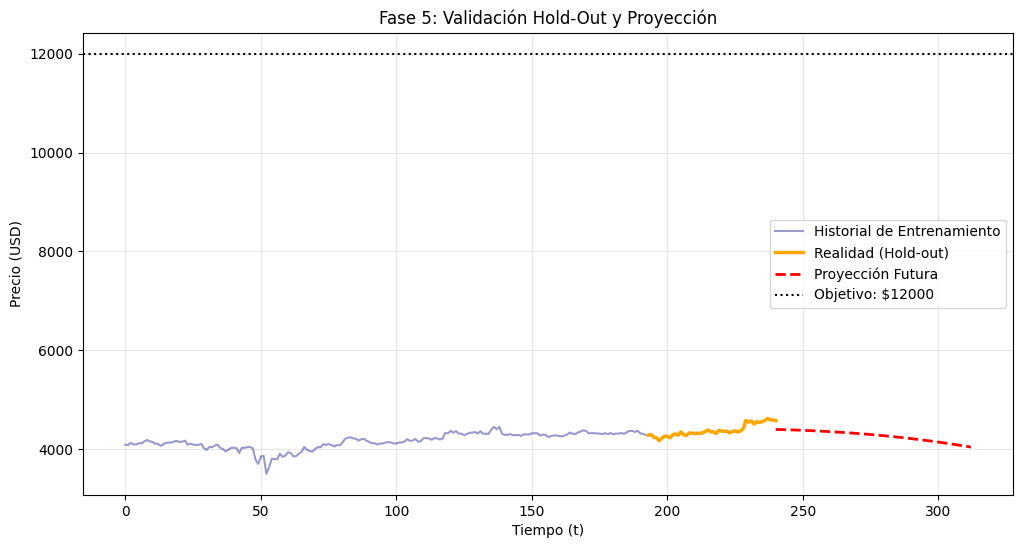

--- REPORTE FINAL DE CALIDAD ---
Error Absoluto (RMSE): $530.65 USD
ERROR RELATIVO: 12.12%
ANÁLISIS DE PRECISIÓN: Aceptable
--------------------------------------------------
Precio objetivo de prueba colocado: $12,000.00 USD
Diferencia actual respecto al objetivo: $7,424.77 USD
--------------------------------------------------
RECOMENDACIÓN FINAL: NO RECOMENDADO: El objetivo es divergente o la fiabilidad es insuficiente.


In [ ]:
#@title Fase 5: Reporte Final de Métricas y Recomendación
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from scipy.optimize import fsolve

# --- 1. CONFIGURACIÓN Y DATOS ---
precio_objetivo = 12000 #@param {type:"number"}
n_prueba = 48  # Tamaño del Hold-out (últimas 48 horas)

# Separación de datos
entrenamiento = df_analisis.iloc[:-n_prueba] # Todo menos las últimas 48h
prueba = df_analisis.iloc[-n_prueba:]        # Solo las últimas 48h (Naranja)

# --- 2. CÁLCULOS INTERNOS (Matemática oculta) ---
# Modelo para validar (entrenado con el pasado)
coef_val = np.polyfit(entrenamiento['t'], entrenamiento['close_price'], 3)
modelo_val = np.poly1d(coef_val)

# Modelo para proyectar (entrenado con todo)
coef_futuro = np.polyfit(df_analisis['t'], df_analisis['close_price'], 3)
modelo_futuro = np.poly1d(coef_futuro)

# Cálculo de errores
y_real = prueba['close_price'].values
y_pred_val = modelo_val(prueba['t'].values) # Predicción interna para calcular el error

rmse_val = np.sqrt(mean_squared_error(y_real, y_pred_val))
precio_medio = y_real.mean()
error_relativo = (rmse_val / precio_medio) * 100
distancia_usd = precio_objetivo - df_analisis['close_price'].iloc[-1]

# --- 3. GRÁFICA ---
plt.figure(figsize=(12, 6))

# Historial (Azul)
plt.plot(entrenamiento['t'], entrenamiento['close_price'],
         color='navy', alpha=0.4, label='Historial de Entrenamiento')

# Realidad Oculta / Hold-out (Naranja)
plt.plot(prueba['t'], y_real,
         color='orange', linewidth=2.5, label='Realidad (Hold-out)')

# Proyección Futura (Roja - La línea que pediste mantener)
t_final = df_analisis['t'].max()
t_proy = np.linspace(t_final, t_final + (n_prueba * 1.5), 50) # Proyecta 72h a futuro
plt.plot(t_proy, modelo_futuro(t_proy),
         color='red', linestyle='--', linewidth=2, label='Proyección Futura')

# Línea de Objetivo
plt.axhline(y=precio_objetivo, color='black', linestyle=':', label=f'Objetivo: ${precio_objetivo}')

plt.title('Fase 5: Validación Hold-Out y Proyección')
plt.xlabel('Tiempo (t)')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- 4. REPORTE IMPRESO (Formato solicitado) ---
print("--- REPORTE FINAL DE CALIDAD ---")
print(f"Error Absoluto (RMSE): ${rmse_val:,.2f} USD")
print(f"ERROR RELATIVO: {error_relativo:.2f}%")
print(f"ANÁLISIS DE PRECISIÓN: {'Alta' if error_relativo < 5 else 'Aceptable' if error_relativo < 15 else 'Baja'}")
print("-" * 50)
print(f"Precio objetivo de prueba colocado: ${precio_objetivo:,.2f} USD")
print(f"Diferencia actual respecto al objetivo: ${distancia_usd:,.2f} USD")
print("-" * 50)

# Lógica para la recomendación final
# Verifica si la proyección futura se acerca al objetivo
precio_futuro_estimado = modelo_futuro(t_final + 24)
va_hacia_objetivo = False

if distancia_usd > 0: # El objetivo es subir
    if precio_futuro_estimado > df_analisis['close_price'].iloc[-1]:
        va_hacia_objetivo = True
else: # El objetivo es bajar (short)
    if precio_futuro_estimado < df_analisis['close_price'].iloc[-1]:
        va_hacia_objetivo = True

if error_relativo < 15 and va_hacia_objetivo:
    print("RECOMENDACIÓN FINAL: RECOMENDADO: El objetivo es coherente con la inercia del modelo.")
else:
    print("RECOMENDACIÓN FINAL: NO RECOMENDADO: El objetivo es divergente o la fiabilidad es insuficiente.")